# QSVT as Matrix Functions: Powers and Roots

QSVT implements polynomial transformations of eigenvalues.

By approximating a function f(x) with a bounded polynomial P(x),
QSVT implements:

    P(A) ≈ f(A)

The examples cover:

- matrix powers
- square roots
- fractional powers

using small matrices to build intuition.

## Variable definitions

- $A$ is the Hermitian matrix whose spectrum is transformed.
- $x$ is a scalar eigenvalue of $A$, $f(x)$ is the target scalar function, and $P(x)$ is its bounded polynomial approximation.
- In $A=U\Lambda U^\dagger$, $U$ is the unitary eigenvector matrix, $\Lambda$ is diagonal, and $U^\dagger$ is the conjugate transpose of $U$.
- A fractional-power parameter $p$ means $f(x)=x^p$ on the non-negative spectrum.

## Notebook guide

- **Learning objective:** apply polynomial approximations to matrix powers and roots.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](05_QSVT_Polynomial_Design_and_Approximation.ipynb) · [next](07_QSVT_Sign_Function_and_Projectors.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.matrices import rotation

from qsvt.spectral import (
    eigh_hermitian,
    apply_function_to_hermitian,
    matrix_power_spectral,
    matrix_square_root,
    matrix_fractional_power,
)

from qsvt.polynomials import (
    eval_polynomial,
)

## 1. Test matrix

In [2]:
theta = 0.6

U = rotation(theta)

lambdas = np.array([0.2, 0.8])

A = U @ np.diag(lambdas) @ U.T

eigvals, eigvecs = eigh_hermitian(A)

print(f"A = {np.round(A, 6)}")

print(f"\nEigenvalues = {eigvals}")

A = [[ 0.391293 -0.279612]
 [-0.279612  0.608707]]

Eigenvalues = [0.2 0.8]


## 2. Integer powers

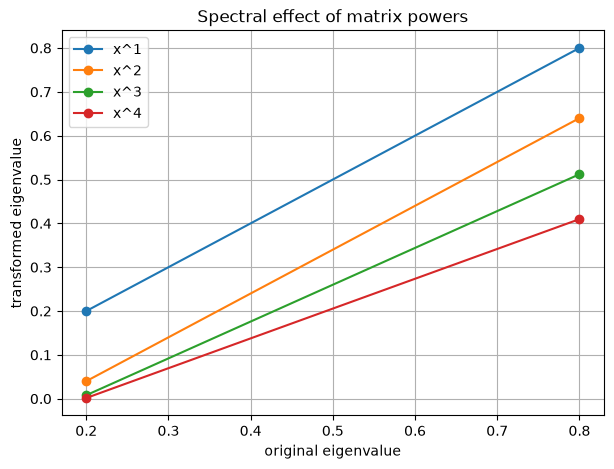

In [3]:
powers = [1, 2, 3, 4]

plt.figure(figsize=(7, 5))

for k in powers:

    eigvals_power = eigvals**k

    plt.plot(eigvals, eigvals_power, "o-", label=f"x^{k}")

plt.xlabel("original eigenvalue")
plt.ylabel("transformed eigenvalue")

plt.title("Spectral effect of matrix powers")

plt.grid(True)
plt.legend()

plt.show()

In [4]:
A2 = matrix_power_spectral(A, 2)

print("A^2 via spectral map:")
print(np.round(A2, 6))

A^2 via spectral map:
[[ 0.231293 -0.279612]
 [-0.279612  0.448707]]


## 3. Polynomial approximation to sqrt(x)

In [5]:
a = 0.2
deg = 6


def sqrt_fn(x):
    return np.sqrt(x)


def chebyshev_fit_on_interval(func, lower, upper, degree, num_points=500):
    """
    Fit a polynomial to func on [lower, upper] using a Chebyshev-basis fit,
    then return standard monomial coefficients in ascending degree order.
    """
    xs = np.linspace(lower, upper, num_points)
    ys = np.asarray(func(xs), dtype=float)

    cheb_coeffs = np.polynomial.chebyshev.chebfit(xs, ys, degree)
    poly = np.polynomial.Chebyshev(cheb_coeffs, domain=[-1.0, 1.0])
    coeffs = poly.convert(kind=np.polynomial.Polynomial).coef

    return np.asarray(coeffs, dtype=float)


coeffs_sqrt = chebyshev_fit_on_interval(
    sqrt_fn,
    lower=a,
    upper=1.0,
    degree=deg,
)

x_fit = np.linspace(a, 1.0, 2001)

print(
    "Bounded on [a,1] [boolean]:",
    bool(np.max(np.abs(eval_polynomial(coeffs_sqrt, x_fit))) <= 1.0 + 1e-8),
)

Bounded on [a,1] [boolean]: True


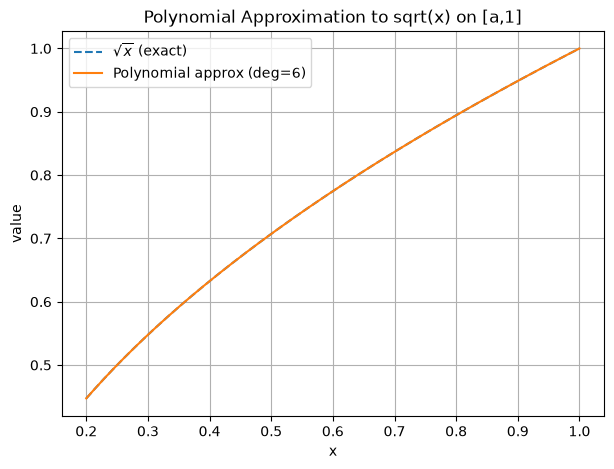

In [6]:
xs = np.linspace(a, 1.0, 400)

plt.figure(figsize=(7, 5))
plt.plot(xs, sqrt_fn(xs), "--", label=r"$\sqrt{x}$ (exact)")
plt.plot(xs, eval_polynomial(coeffs_sqrt, xs), label=f"Polynomial approx (deg={deg})")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Polynomial Approximation to sqrt(x) on [a,1]")
plt.grid(True)
plt.legend()
plt.show()

## 4. Applying sqrt(A)

In [7]:
sqrtA_exact = matrix_square_root(A)

sqrtA_poly = apply_function_to_hermitian(A, lambda x: eval_polynomial(coeffs_sqrt, x))

print("sqrt(A) exact:")
print(np.round(sqrtA_exact, 6))

print("\nsqrt(A) polynomial:")
print(np.round(sqrtA_poly, 6))

sqrt(A) exact:
[[ 0.589795 -0.20841 ]
 [-0.20841   0.751846]]

sqrt(A) polynomial:
[[ 0.589848 -0.208365]
 [-0.208365  0.751864]]


## 5. Fractional powers

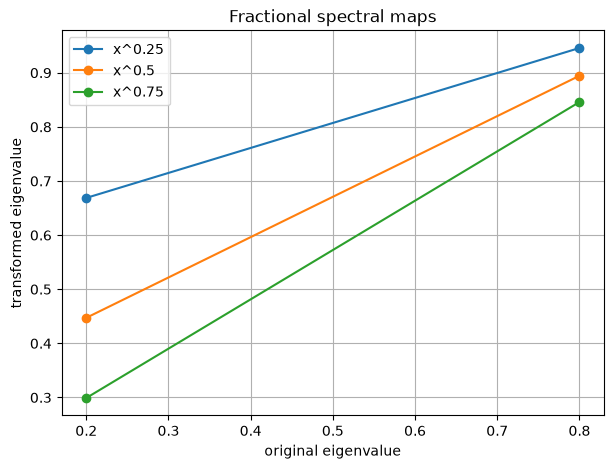

In [8]:
alphas = [0.25, 0.5, 0.75]

plt.figure(figsize=(7, 5))

for alpha in alphas:

    plt.plot(eigvals, eigvals**alpha, "o-", label=f"x^{alpha}")

plt.xlabel("original eigenvalue")
plt.ylabel("transformed eigenvalue")

plt.title("Fractional spectral maps")

plt.grid(True)
plt.legend()

plt.show()

In [9]:
A_half = matrix_fractional_power(A, 0.5)

print("A^0.5 via spectral routine:")
print(np.round(A_half, 6))

A^0.5 via spectral routine:
[[ 0.589795 -0.20841 ]
 [-0.20841   0.751846]]


## Summary

Matrix functions act spectrally:

    f(A) = U f(Λ) U†

QSVT implements polynomial approximations to these maps.

Powers, roots, and fractional transforms are all accessible
through bounded polynomial design.

## Validation

Compact checks for the expected tutorial behavior.


In [10]:
assert np.allclose(A2, A @ A, atol=1e-10)
assert np.allclose(sqrtA_exact @ sqrtA_exact, A, atol=1e-10)
assert np.allclose(sqrtA_poly, sqrtA_exact, atol=1e-3)
assert np.allclose(A_half, sqrtA_exact, atol=1e-10)

print(f"sqrt_poly_max_error: {np.max(np.abs(sqrtA_poly - sqrtA_exact)):.3e}")
print(f"spectral_square_error: {np.max(np.abs(A2 - A @ A)):.3e}")
print("validation: passed")

sqrt_poly_max_error: 5.293e-05
spectral_square_error: 3.331e-16
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to apply polynomial approximations to matrix powers and roots.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](05_QSVT_Polynomial_Design_and_Approximation.ipynb) · [next](07_QSVT_Sign_Function_and_Projectors.ipynb).
